# Expected Free energy minimization for mobile robot navigation

### Joost Leliveld, last update: 06-02-2026  
Heavily inspired from Wouter Kouw

### Usecase:

A robot that moves according to the constant-velocity model is observed by an external static camera. The camera provides image measurements (pixel location) to help the robot navigate from point A to point B. The ground is assumed to be planar and the camera intrinsics as well as the homography known. This makes the observation model nonlinear and the effects of this will be studied for different control types. 

### Dynamics (linear constant-velocity model)

Consider a robot that moves according to the constant-velocity model:

$$\underbrace{\begin{bmatrix} x_{1,k} \\ x_{2,k} \\ \dot{x}_{1,k} \\ \dot{x}_{2,k} \end{bmatrix}}_{z_k}
=
\underbrace{\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x_{1,k-1} \\ x_{2,k-1} \\ \dot{x}_{1,k-1} \\ \dot{x}_{2,k-1} \end{bmatrix}}_{z_{k-1}}
+
\underbrace{\begin{bmatrix}
0 & 0 \\
0 & 0 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}}_{B}
\underbrace{\begin{bmatrix} u_{1,k} \\ u_{2,k} \end{bmatrix}}_{u_k}
+ q_k\, .$$


Process noise is white, $q_k \sim \mathcal{N}(0,Q)$, with

$$Q =
\begin{bmatrix}
\frac{\Delta t^3}{3}\rho_1 & 0 & \frac{\Delta t^2}{2}\rho_1 & 0 \\
0 & \frac{\Delta t^3}{3}\rho_2 & 0 & \frac{\Delta t^2}{2}\rho_2 \\
\frac{\Delta t^2}{2}\rho_1 & 0 & \Delta t\rho_1 & 0 \\
0 & \frac{\Delta t^2}{2}\rho_2 & 0 & \Delta t\rho_2
\end{bmatrix}\, .$$


### Observations: external oblique camera (pixels)

A static external camera observes the robot in the image plane. The measurement is the pixel location:

$$o_k \triangleq \begin{bmatrix} u_k^{\mathrm{pix}} \\ v_k^{\mathrm{pix}} \end{bmatrix} \in \mathbb{R}^2.$$

The camera measurement is generated by a nonlinear projective mapping:

$$o_k = g(z_k) + r_k,\qquad r_k \sim \mathcal{N}(0,R),$$

where $g(z_k)$ is defined as the composition of (i) ground-plane embedding into 3D, (ii) rigid transform into the camera frame, and (iii) perspective projection to pixels. Since the camera observes position on the ground plane, the observation model depends only on the position components. 

#### Projective mapping (state $\rightarrow$ pixels)
https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html 
1) **Embed the ground-plane point into 3D (world frame).**  
Assuming a planar ground ($Z=0$):

$$P_w(p_k) \triangleq \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
=
\begin{bmatrix} x_{1,k} \\ x_{2,k} \\ 0 \\ 1 \end{bmatrix}.$$

2) **Transform world coordinates to camera coordinates.**  
Let $(R_{cw},t_{cw})$ be the camera extrinsics (world-to-camera):

$$\begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix}
=
R_{cw}\begin{bmatrix} X \\ Y \\ Z \end{bmatrix} + t_{cw}.$$

3) **Perspective division (nonlinearity).**  
Normalized image coordinates are obtained by:

$$x_n = \frac{X_c}{Z_c},\qquad y_n = \frac{Y_c}{Z_c}.$$

4) **Intrinsics map normalized coordinates to pixels.**  
With camera intrinsics $(f_x,f_y,c_x,c_y)$:

$$u_k^{\mathrm{pix}} = f_x x_n + c_x,\qquad
v_k^{\mathrm{pix}} = f_y y_n + c_y.$$

Putting these steps together defines $g(z_k)$:

$$g(z_k) \triangleq 
\begin{bmatrix}
f_x \frac{X_c(p_k)}{Z_c(p_k)} + c_x \\
f_y \frac{Y_c(p_k)}{Z_c(p_k)} + c_y
\end{bmatrix},
\qquad p_k = C z_k.$$

The mapping is nonlinear because of the perspective division by $Z_c(p_k)$, which induces state-dependent sensitivity of pixels to changes in ground-plane position.


### Probabilistic model

We use a probabilistic state-space model with linear-Gaussian dynamics and a nonlinear camera observation model:

$$\begin{align}
p(z_0) &= \mathcal{N}(z_0 \mid m_0, S_0) \\
p(z_k \mid z_{k-1}, u_k) &= \mathcal{N}(z_k \mid A z_{k-1} + B u_k, Q) \\
p(o_k \mid z_k) &= \mathcal{N}(o_k \mid g(z_k), R)\, .
\end{align}$$

Here, $z_k \in \mathbb{R}^4$ is the ground-plane constant-velocity state and $o_k$ is the external camera measurement in the image plane. 


### Gaussian approximation to likelihood

Because $g(\cdot)$ is nonlinear, the likelihood $p(o_k \mid z_k)$ is generally non-Gaussian as a function of $z_k$:

Using the projective observation model,

$$
g(z_k)
=
\begin{bmatrix}
f_x \dfrac{X_c(p_k)}{Z_c(p_k)} + c_x \\
f_y \dfrac{Y_c(p_k)}{Z_c(p_k)} + c_y
\end{bmatrix},
$$

the likelihood can be written (up to a normalization constant) as

$$
p(o_k \mid z_k)
=
\frac{1}{\sqrt{(2\pi)^2 \det R}}
\exp\!\Big(-\tfrac12 (o_k-g(z_k))^\top R^{-1}(o_k-g(z_k))\Big).
$$


$$
\log p(o_k \mid z_k)
=
-\tfrac12 \big(o_k - g(z_k)\big)^\top R^{-1} \big(o_k - g(z_k)\big).
$$

Since the term is not just a power of o or z the likelihood is non-Gaussian, however we approximate the joint $(z_k, o_k)$ as a Gaussian:

$$p(o_k, z_k) \approx \mathcal{N}\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix} S_k & \Gamma_k \\ \Gamma_k^{\top} & \Sigma_k \end{bmatrix}
\right)\, .$$

Here:
- $m_k, S_k$ are the predicted state mean and covariance,
- $\mu_k, \Sigma_k$ are the predicted observation mean and covariance,
- $\Gamma_k$ is the state--observation cross-covariance.

Because this joint is Gaussian, conditioning yields an approximate Gaussian likelihood:

$$\begin{align}
p(o_k \mid z_k)
&\approx \mathcal{N}\!\left(
o_k \,\Big|\,
\mu_k + \Gamma_k^{\top} S_k^{-1}(z_k - m_k),
\ \Sigma_k - \Gamma_k^{\top} S_k^{-1}\Gamma_k
\right)\, .
\end{align}$$

The parameters $(\mu_k, \Sigma_k, \Gamma_k)$ are obtained by a Gaussian approximation method:
first-order Taylor (ET1/EFE1), second-order Taylor (ET2/EFE2), or sigma-point (UT) approximation.


## Posterior predictive

The posterior predictive distribution of the observation is obtained by marginalizing
over the latent state:

$$
\begin{align}
p(o_k \mid o_{1:k-1})
&= \int p(o_k \mid z_k)\, p(z_k \mid o_{1:k-1}) \, dz_k \tag{1}\\
&= \int \mathcal N\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix}
S_k & \Gamma_k \\
\Gamma_k^\top & \Sigma_k
\end{bmatrix}
\right) dz_k \tag{2}\\
&= \mathcal N(o_k \mid \mu_k, \Sigma_k). \tag{3}
\end{align}
$$

That is, marginalizing a joint Gaussian yields a Gaussian predictive distribution
with mean $\mu_k$ and covariance $\Sigma_k$.


## Planning and control

### Expected Free Energy (EFE) objective

The Expected Free Energy objective for a single time step is given by

$$
\mathcal J_k(u_t)
=
\mathcal C
+
\frac{1}{2}\,\mathrm{tr}\!\left(S_*^{-1}(\Sigma_t + \Sigma_\star)\right)
+
\frac{1}{2}\,\ln
\frac{\left| \Sigma_t - \Gamma_t^\top S_t^{-1} \Gamma_t \right|}
{\left| \Sigma_t \right|}. \tag{1}
$$

The first term encodes the expected risk, while the log-determinant term captures
expected ambiguity through the conditional observation covariance.

### Horizon-based control optimization

For a planning horizon of $T$ steps, the optimal control sequence is obtained as

$$
\begin{align}
\hat u
&= \arg\max_{u \in \mathcal U} q^\star(u) \tag{1}\\
&= \arg\min_{u \in \mathcal U}
\sum_{t=1}^{T} \mathcal J_t(u_t)
- \ln p(u_t). \tag{2}
\end{align}
$$


In [1]:
from pathlib import Path
import sys

CWD = Path.cwd()
ROOT = CWD if (CWD / "scripts").exists() else CWD.parent

sys.path.insert(0, str(ROOT / "scripts"))



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from tqdm import tqdm

from robots import FieldBot, update
from botnav_efe_helpers import PlanarCamera, EFEAgent, predict, correct, EFE, evidence, planned_trajectory

# Matplotlib settings
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 3

# Helper function to plot covariance ellipse
def plot_cov_ellipse(ax, mean, cov, n_std=1, color='blue', alpha=0.3, linewidth=0):
    # Plot covariance ellipse
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    order = eigenvals.argsort()[::-1]
    eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]

    angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvals)

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  color=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ell)


In [10]:
# Time
Δt = 0.2
len_trial = 20
tsteps = np.arange(0, len_trial * Δt, Δt)
len_horizon = 3

# Camera parameters (arbitrary)
cam_pos = np.array([-3.0, -3.0, 6.0])
look_at = np.array([1.5, 1.5, 0.0])
img_width = 1920
img_height = 1080
fov_h_rad = np.deg2rad(90.0)

camera = PlanarCamera(
    cam_pos=cam_pos,
    look_at=look_at,
    img_width=img_width,
    img_height=img_height,
    fov_h_rad=fov_h_rad,
)

# Build H as jax array once
H_j = jnp.array(camera.H)

def g(x):
    # x is JAX array
    world = jnp.array([x[0], x[1], 1.0])
    pix = H_j @ world
    u = pix[0] / pix[2]
    v = pix[1] / pix[2]
    return jnp.array([u, v])


# Setpoint (desired observation)
z_star = np.array([0.0, 1.0, 0.0, 0.0])
goal_sigma_pix = 5.0
goal_obs = g(z_star)
goal = (goal_obs, goal_sigma_pix ** 2 * np.eye(goal_obs.size))

# Parameters
σ_pix = 2.0
ρ = np.array([1e-2, 1e-2])
η = 0.0

# Limits of controller
u_lims = (-1.0, 1.0)

# Initial state
z_0 = np.array([0.0, -1.0, 0.0, 0.0])

# Initial belief
m_0 = z_0.copy()
S_0 = 0.1 * np.diag(np.ones(4))

fbot = FieldBot(g, ρ, σ=σ_pix, Δt=Δt, control_lims=u_lims)
fbot.R = np.diag(σ_pix ** 2 * np.ones(2))
agent = EFEAgent(goal, g, ρ, sigma=σ_pix, eta=η, dt=Δt, time_horizon=len_horizon)


# Output folders
FIG_DIR = ROOT / "scripts" / "figures"
ANIM_DIR = ROOT / "scripts" / "animations"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ANIM_DIR.mkdir(parents=True, exist_ok=True)


## Model: EFE(ET2)

In [11]:
# --- add once (outside loop) ---
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

A_j = jnp.array(agent.A)
B_j = jnp.array(agent.B)
Q_j = jnp.array(agent.Q)
R_j = jnp.array(agent.R)
goal_mu_j = jnp.array(agent.goal[0])
goal_S_j = jnp.array(agent.goal[1])
eta_val = float(getattr(agent, "η", getattr(agent, "eta", 0.0)))

def ET2_jax(m, S):
    Jm = jax.jacfwd(g)(m)
    H = jax.jacfwd(jax.jacrev(g))(m)
    aux1 = jnp.array([jnp.trace(H[i] @ S) for i in range(H.shape[0])])
    aux2 = jnp.array([
        [jnp.trace(H[i] @ S @ H[j] @ S) for j in range(H.shape[0])]
        for i in range(H.shape[0])
    ])
    mu = g(m) + 0.5 * aux1
    Sigma = Jm @ S @ Jm.T + 0.5 * aux2 + R_j
    Gamma = S @ Jm.T
    return mu, Sigma, Gamma

def risk_jax(mu, Sigma):
    eps = 1e-9
    L0 = jnp.linalg.cholesky(Sigma + eps * jnp.eye(Sigma.shape[0]))
    L1 = jnp.linalg.cholesky(goal_S_j + eps * jnp.eye(goal_S_j.shape[0]))
    M = jnp.linalg.solve(L1, L0)
    y = jnp.linalg.solve(L1, goal_mu_j - mu)
    D = goal_mu_j.shape[0]
    return 0.5 * (jnp.sum(M**2) - D + jnp.sum(y**2) +
                  2.0 * jnp.sum(jnp.log(jnp.diag(L1) / jnp.diag(L0))))

def ambiguity_jax(Sigma, Gamma, S):
    Sigma_cond = Sigma - Gamma.T @ jnp.linalg.solve(S, Gamma)
    sign, logdet = jnp.linalg.slogdet(Sigma_cond)
    d = Sigma_cond.shape[0]
    return 0.5 * (d * jnp.log(2 * jnp.pi * jnp.e) + logdet)

def EFE_jax(u, m0, S0, add_ambiguity=True):
    u = u.reshape((agent.time_horizon, agent.Du))
    m = m0
    S = S0
    cost = 0.0
    for t in range(agent.time_horizon):
        m = A_j @ m + B_j @ u[t]
        S = A_j @ S @ A_j.T + Q_j
        mu, Sigma, Gamma = ET2_jax(m, S)
        cost += risk_jax(mu, Sigma) + eta_val * jnp.sum(u[t]**2)
        if add_ambiguity:
            cost += ambiguity_jax(Sigma, Gamma, S)
    return cost



In [12]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

@jax.jit
def G_valgrad_fwd(u, m, S):
    # forward-mode gradient (like Julia ForwardDiff)
    val = EFE_jax(u, m, S, add_ambiguity=True)
    grad = jax.jacfwd(lambda uu: EFE_jax(uu, m, S, add_ambiguity=True))(u)
    return val, grad

z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))
z_pln = (np.zeros((len_trial, 4, len_horizon)), np.zeros((len_trial, 4, 4, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((4, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE2 = np.zeros(len_trial)
J_EFE2 = np.zeros(len_trial)

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE2 Experiment"):

    # Interact with environment
    # Update system with selected control
    y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence
    F_EFE2[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")
    J_EFE2[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    # Single-argument objective
    def G(u):
        return EFE(agent, u, (m_k, S_k), approx="ET2")

    # Call minimizer using constrained L-BFGS procedure
    # Set up bounds for all control variables
    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]
    m_k_j = jnp.array(m_k)
    S_k_j = jnp.array(S_k)

    def f(u):
        val, _ = G_valgrad_fwd(jnp.array(u), m_k_j, S_k_j)
        return np.array(val)

    def grad_u(u):
        _, grad = G_valgrad_fwd(jnp.array(u), m_k_j, S_k_j)
        return np.array(grad)

    result = minimize(
        f,
        np.zeros(2 * len_horizon),  # cold start like Julia
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )


    # Extract minimizing control
    policy = result.x.reshape((2, len_horizon))
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE2 Experiment: 100%|██████████| 19/19 [00:11<00:00,  1.60it/s]


In [13]:
xl = [-2., 3.]
yl = [-1.5, 2.5]

# Create animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(xl)
ax.set_ylim(yl)
ax.set_aspect('equal')
ax.set_xlabel("position x")
ax.set_ylabel("position y")
ax.grid(False)

def animate_frame(k):
    ax.clear()
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_aspect('equal')
    ax.set_title(f"{k+1}/{len_trial}")
    ax.set_xlabel("position x")
    ax.set_ylabel("position y")

    # Start and goal
    ax.scatter([z_0[0]], [z_0[1]], color="blue", label="start", s=25)
    ax.scatter([z_star[0]], [z_star[1]], color="red", label="goal state", s=25)

    # True trajectory
    ax.plot(z_sim[0, 1:k+1], z_sim[1, 1:k+1], c="blue", label="true", alpha=0.5)

    # Inferred trajectory
    ax.plot(z_est[0][0, 1:k+1], z_est[0][1, 1:k+1], c="purple", label="inferred", alpha=0.5)
    plot_cov_ellipse(ax, z_est[0][0:2, k], z_est[1][0:2, 0:2, k],
                     n_std=1, color="purple", alpha=0.3, linewidth=0)

    # Planned trajectory
    ax.plot(z_pln[0][k, 0, :], z_pln[0][k, 1, :], c="orange", label="planned")
    for j in range(len_horizon):
        plot_cov_ellipse(ax, z_pln[0][k, 0:2, j], z_pln[1][k, 0:2, 0:2, j],
                         n_std=1, color="orange", alpha=0.3, linewidth=0)

    if k == 2:  # Show legend only once
        ax.legend(loc='upper left')

anim = FuncAnimation(fig, animate_frame, frames=range(2, len_trial), interval=1000, repeat=False)
anim.save(str(ANIM_DIR / "bev2image-experiment-EFE2-path.gif"), writer=PillowWriter(fps=1))
plt.close()


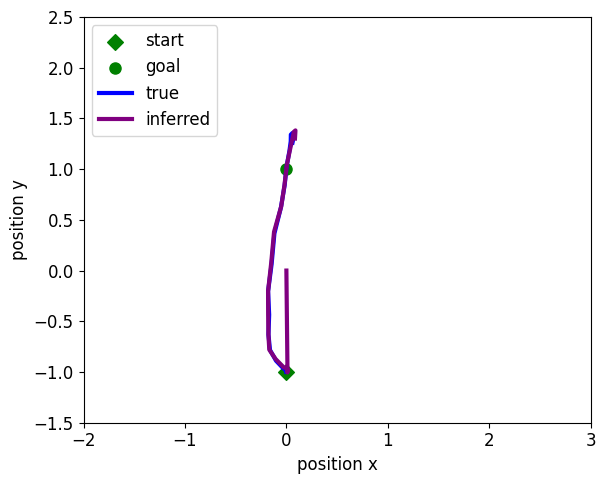

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(xl)
ax.set_ylim(yl)
ax.set_xlabel("position x")
ax.set_ylabel("position y")
ax.set_aspect('equal')

ax.scatter([z_0[0]], [z_0[1]], color="green", marker='D', label="start", s=64)
ax.scatter([z_star[0]], [z_star[1]], color="green", label="goal", s=64)

ax.plot(z_sim[0, :], z_sim[1, :], c="blue", label="true")
ax.plot(z_est[0][0, :], z_est[0][1, :], c="purple", label="inferred")

for j in range(len_trial):
    plot_cov_ellipse(ax, z_est[0][0:2, j], z_est[1][0:2, 0:2, j],
                     n_std=1, color="purple", alpha=0.1, linewidth=0)

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [15]:
plt.savefig(FIG_DIR / "bev2image-experiment-EFE2-path.png", dpi=150, bbox_inches='tight')
plt.close()


In [17]:
# Preallocate
z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))
z_pln = (np.zeros((len_trial, 4, len_horizon)), np.zeros((len_trial, 4, 4, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((4, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE1 = np.zeros(len_trial)
J_EFE1 = np.zeros(len_trial)

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

# Initialize policy
policy = np.zeros(2 * len_horizon)

for k in tqdm(range(1, len_trial), desc="EFE1 Experiment"):

    # Interact with environment
    # Update system with selected control
    y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")

    # Compute model evidence
    F_EFE1[k] = evidence(agent, y_sim[:, k], m_k, S_k, approx="ET2")
    J_EFE1[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    # Single-argument objective
    def G(u):
        return EFE(agent, u, (m_k, S_k), approx="ET1")

    # Call minimizer using constrained L-BFGS procedure
    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]
    result = minimize(G, np.zeros(2 * len_horizon), method='L-BFGS-B', bounds=bounds,
                      options={'maxiter': 1000, 'maxfun': 10000})

    # Extract minimizing control
    policy = result.x.reshape((2, len_horizon))
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory(agent, policy, (m_k, S_k), approx="ET1")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE1 Experiment: 100%|██████████| 19/19 [00:02<00:00,  7.98it/s]


In [18]:
# Create animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(xl)
ax.set_ylim(yl)
ax.set_aspect('equal')
ax.set_xlabel("position x")
ax.set_ylabel("position y")
ax.grid(False)

def animate_frame(k):
    ax.clear()
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_aspect('equal')
    ax.set_title(f"{k+1}/{len_trial}")
    ax.set_xlabel("position x")
    ax.set_ylabel("position y")

    # Start and goal
    ax.scatter([z_0[0]], [z_0[1]], color="blue", label="start", s=25)
    ax.scatter([z_star[0]], [z_star[1]], color="red", label="goal state", s=25)

    # True trajectory
    ax.plot(z_sim[0, 1:k+1], z_sim[1, 1:k+1], c="blue", label="true", alpha=0.5)

    # Inferred trajectory
    ax.plot(z_est[0][0, 1:k+1], z_est[0][1, 1:k+1], c="purple", label="inferred", alpha=0.5)
    plot_cov_ellipse(ax, z_est[0][0:2, k], z_est[1][0:2, 0:2, k],
                     n_std=1, color="purple", alpha=0.3, linewidth=0)

    # Planned trajectory
    ax.plot(z_pln[0][k, 0, :], z_pln[0][k, 1, :], c="orange", label="planned")
    for j in range(len_horizon):
        plot_cov_ellipse(ax, z_pln[0][k, 0:2, j], z_pln[1][k, 0:2, 0:2, j],
                         n_std=1, color="orange", alpha=0.3, linewidth=0)

    if k == 2:  # Show legend only once
        ax.legend(loc='upper left')

anim = FuncAnimation(fig, animate_frame, frames=range(2, len_trial), interval=333, repeat=False)
anim.save(str(ANIM_DIR / "bev2image-experiment-EFE1-path.gif"), writer=PillowWriter(fps=3))
plt.close()


In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(xl)
ax.set_ylim(yl)
ax.set_xlabel("position x")
ax.set_ylabel("position y")
ax.set_aspect('equal')

ax.scatter([z_0[0]], [z_0[1]], color="green", marker='D', label="start", s=64)
ax.scatter([z_star[0]], [z_star[1]], color="green", label="goal", s=64)

ax.plot(z_sim[0, :], z_sim[1, :], c="blue", label="true")
ax.plot(z_est[0][0, :], z_est[0][1, :], c="purple", label="inferred")

for j in range(len_trial):
    plot_cov_ellipse(ax, z_est[0][0:2, j], z_est[1][0:2, 0:2, j],
                     n_std=1, color="purple", alpha=0.1, linewidth=0)

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


/tmp/ipykernel_40900/3863976964.py:20: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [20]:
plt.savefig(FIG_DIR / "bev2image-experiment-EFE1-path.png", dpi=150, bbox_inches='tight')
plt.close()


In [26]:
# Preallocate
z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))
z_pln = (np.zeros((len_trial, 4, len_horizon)), np.zeros((len_trial, 4, 4, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((4, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFER = np.zeros(len_trial)
J_EFER = np.zeros(len_trial)

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

# Initialize policy
policy = np.zeros(2 * len_horizon)

for k in tqdm(range(1, len_trial), desc="EFER Experiment"):

    # Interact with environment
    # Update system with selected control
    y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence
    F_EFER[k] = evidence(agent, y_sim[:, k], m_k, S_k, approx="ET2")
    J_EFER[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    # Single-argument objective
    def G(u):
        return EFE(agent, u, (m_k, S_k), approx="ET2", add_ambiguity=False)

    # Call minimizer using constrained L-BFGS procedure
    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]
    result = minimize(G, np.zeros(2 * len_horizon), method='L-BFGS-B', bounds=bounds,
                      options={'maxiter': 1000, 'maxfun': 10000})

    # Extract minimizing control
    policy = result.x.reshape((2, len_horizon))
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFER Experiment: 100%|██████████| 19/19 [00:07<00:00,  2.41it/s]


In [27]:
# Create animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(xl)
ax.set_ylim(yl)
ax.set_aspect('equal')
ax.set_xlabel("position x")
ax.set_ylabel("position y")
ax.grid(False)

def animate_frame(k):
    ax.clear()
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_aspect('equal')
    ax.set_title(f"{k+1}/{len_trial}")
    ax.set_xlabel("position x")
    ax.set_ylabel("position y")

    # Start and goal
    ax.scatter([z_0[0]], [z_0[1]], color="blue", label="start", s=25)
    ax.scatter([z_star[0]], [z_star[1]], color="red", label="goal state", s=25)

    # True trajectory
    ax.plot(z_sim[0, 1:k+1], z_sim[1, 1:k+1], c="blue", label="true", alpha=0.5)

    # Inferred trajectory
    ax.plot(z_est[0][0, 1:k+1], z_est[0][1, 1:k+1], c="purple", label="inferred", alpha=0.5)
    plot_cov_ellipse(ax, z_est[0][0:2, k], z_est[1][0:2, 0:2, k],
                     n_std=1, color="purple", alpha=0.3, linewidth=0)

    # Planned trajectory
    ax.plot(z_pln[0][k, 0, :], z_pln[0][k, 1, :], c="orange", label="planned")
    for j in range(len_horizon):
        plot_cov_ellipse(ax, z_pln[0][k, 0:2, j], z_pln[1][k, 0:2, 0:2, j],
                         n_std=1, color="orange", alpha=0.3, linewidth=0)

    if k == 2:  # Show legend only once
        ax.legend(loc='upper left')

anim = FuncAnimation(fig, animate_frame, frames=range(2, len_trial), interval=333, repeat=False)
anim.save(str(ANIM_DIR / "bev2image-experiment-EFER-path.gif"), writer=PillowWriter(fps=3))
plt.close()


In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(xl)
ax.set_ylim(yl)
ax.set_xlabel("position x")
ax.set_ylabel("position y")
ax.set_aspect('equal')

ax.scatter([z_0[0]], [z_0[1]], color="green", marker='D', label="start", s=64)
ax.scatter([z_star[0]], [z_star[1]], color="green", label="goal", s=64)

ax.plot(z_sim[0, :], z_sim[1, :], c="blue", label="true")
ax.plot(z_est[0][0, :], z_est[0][1, :], c="purple", label="inferred")

for j in range(len_trial):
    plot_cov_ellipse(ax, z_est[0][0:2, j], z_est[1][0:2, 0:2, j],
                     n_std=1, color="purple", alpha=0.1, linewidth=0)

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


/tmp/ipykernel_40900/3863976964.py:20: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [29]:
plt.savefig(FIG_DIR / "bev2image-experiment-EFER-path.png", dpi=150, bbox_inches='tight')
plt.close()


In [16]:
tF_EFE2 = np.sum(F_EFE2)
tF_EFE1 = np.sum(F_EFE1)
tF_EFER = np.sum(F_EFER)

print(f"F EFE2 = {tF_EFE2}")
print(f"F EFE1 = {tF_EFE1}")
print(f"F EFER = {tF_EFER}")


NameError: name 'F_EFE1' is not defined

In [31]:
tJ_EFE2 = np.sum(J_EFE2)
tJ_EFE1 = np.sum(J_EFE1)
tJ_EFER = np.sum(J_EFER)

print(f"Total goal prior -log-likelihood EFE2 = {tJ_EFE2}")
print(f"Total goal prior -log-likelihood EFE1 = {tJ_EFE1}")
print(f"Total goal prior -log-likelihood EFER = {tJ_EFER}")

Total goal prior -log-likelihood EFE2 = 7819.98922624858
Total goal prior -log-likelihood EFE1 = 7879.176255512133
Total goal prior -log-likelihood EFER = 9942.672724709964


In [32]:
perf_EFE2 = np.sum(F_EFE2) + np.sum(J_EFE2)
perf_EFE1 = np.sum(F_EFE1) + np.sum(J_EFE1)
perf_EFER = np.sum(F_EFER) + np.sum(J_EFER)

print(f"Performance EFE2 = {perf_EFE2}")
print(f"Performance EFE1 = {perf_EFE1}")
print(f"Performance EFER = {perf_EFER}")

Performance EFE2 = 7919.129076555148
Performance EFE1 = 7954.310741258302
Performance EFER = 10019.422882409024


In [ ]:
# --- Camera nonlinearity sweep: ET1 vs ET2 comparison ---

# Choose a sweep (edit these lists to taste)
heights = [3.0, 6.0, 9.0]        # camera z height
fovs_deg = [60.0, 90.0, 120.0]   # horizontal FOV
look_at = np.array([1.5, 1.5, 0.0])  # keep fixed for now

camera_grid = []
for z in heights:
    for fdeg in fovs_deg:
        camera_grid.append({
            "cam_pos": np.array([-3.0, -3.0, z]),
            "look_at": look_at,
            "img_width": 1920,
            "img_height": 1080,
            "fov_h_rad": np.deg2rad(fdeg),
        })

def run_trial(camera_params, approx="ET2", add_ambiguity=True, seed=0):
    np.random.seed(seed)

    camera = PlanarCamera(**camera_params)

    # NumPy g for sim/filter
    def g_np(x):
        return camera.g(x)

    # JAX g for optimizer
    H_j = jnp.array(camera.H)
    def g_jax(x):
        world = jnp.array([x[0], x[1], 1.0])
        pix = H_j @ world
        return jnp.array([pix[0] / pix[2], pix[1] / pix[2]])

    goal_obs = g_np(z_star)
    goal = (goal_obs, goal_sigma_pix ** 2 * np.eye(goal_obs.size))

    fbot_local = FieldBot(g_np, ρ, σ_pix, Δt, u_lims)
    fbot_local.R = np.diag(σ_pix ** 2 * np.ones(goal_obs.size))

    agent_local = EFEAgent(goal, g_np, ρ, sigma=σ_pix, eta=η, dt=Δt, time_horizon=len_horizon)

    # JAX constants for EFE_jax
    A_j = jnp.array(agent_local.A)
    B_j = jnp.array(agent_local.B)
    Q_j = jnp.array(agent_local.Q)
    R_j = jnp.array(agent_local.R)
    goal_mu_j = jnp.array(goal[0])
    goal_S_j = jnp.array(goal[1])

    def ET2_jax(m, S):
        Jm = jax.jacfwd(g_jax)(m)
        H = jax.jacfwd(jax.jacrev(g_jax))(m)
        aux1 = jnp.array([jnp.trace(H[i] @ S) for i in range(H.shape[0])])
        aux2 = jnp.array([[jnp.trace(H[i] @ S @ H[j] @ S)
                           for j in range(H.shape[0])]
                          for i in range(H.shape[0])])
        mu = g_jax(m) + 0.5 * aux1
        Sigma = Jm @ S @ Jm.T + 0.5 * aux2 + R_j
        Gamma = S @ Jm.T
        return mu, Sigma, Gamma

    def risk_jax(mu, Sigma):
        eps = 1e-9
        L0 = jnp.linalg.cholesky(Sigma + eps * jnp.eye(Sigma.shape[0]))
        L1 = jnp.linalg.cholesky(goal_S_j + eps * jnp.eye(goal_S_j.shape[0]))
        M = jnp.linalg.solve(L1, L0)
        y = jnp.linalg.solve(L1, goal_mu_j - mu)
        D = goal_mu_j.shape[0]
        return 0.5 * (jnp.sum(M**2) - D + jnp.sum(y**2) +
                      2.0 * jnp.sum(jnp.log(jnp.diag(L1) / jnp.diag(L0))))

    def ambiguity_jax(Sigma, Gamma, S):
        Sigma_cond = Sigma - Gamma.T @ jnp.linalg.solve(S, Gamma)
        sign, logdet = jnp.linalg.slogdet(Sigma_cond)
        d = Sigma_cond.shape[0]
        return 0.5 * (d * jnp.log(2 * jnp.pi * jnp.e) + logdet)

    def EFE_jax(u, m0, S0, add_ambiguity=True):
        u = u.reshape((agent_local.time_horizon, agent_local.Du))
        m = m0
        S = S0
        cost = 0.0
        for t in range(agent_local.time_horizon):
            m = A_j @ m + B_j @ u[t]
            S = A_j @ S @ A_j.T + Q_j
            mu, Sigma, Gamma = ET2_jax(m, S)
            cost += risk_jax(mu, Sigma)
            if add_ambiguity:
                cost += ambiguity_jax(Sigma, Gamma, S)
        return cost

    @jax.jit
    def G_valgrad(u, m, S):
        return jax.value_and_grad(lambda uu: EFE_jax(uu, m, S, add_ambiguity=add_ambiguity))(u)

    z_sim = np.zeros((4, len_trial))
    y_sim = np.zeros((agent_local.Dy, len_trial))
    u_sim = np.zeros((2, len_trial))
    F = np.zeros(len_trial)
    J = np.zeros(len_trial)

    z_sim[:, 0] = z_0
    m_kmin1 = m_0
    S_kmin1 = S_0
    policy = np.zeros((2, len_horizon))

    for k in range(1, len_trial):
        y_sim[:, k], z_sim[:, k] = update(fbot_local, z_sim[:, k-1], u_sim[:, k-1])

        m_k_pred, S_k_pred = predict(agent_local, m_kmin1, S_kmin1, u_sim[:, k-1])
        m_k, S_k = correct(agent_local, y_sim[:, k], m_k_pred, S_k_pred, approx=approx)

        F[k] = evidence(agent_local, y_sim[:, k], m_k_pred, S_k_pred, approx=approx)
        J[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

        bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]
        m_k_j = jnp.array(m_k)
        S_k_j = jnp.array(S_k)

        def f(u):
            val, _ = G_valgrad(jnp.array(u), m_k_j, S_k_j)
            return np.array(val)

        def grad_u(u):
            _, grad = G_valgrad(jnp.array(u), m_k_j, S_k_j)
            return np.array(grad)

        result = minimize(
            f,
            policy.flatten(),
            jac=grad_u,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
        )

        policy = result.x.reshape((2, len_horizon))
        u_sim[:, k] = policy[:, 0]

        m_kmin1 = m_k
        S_kmin1 = S_k

    return float(np.sum(F)), float(np.sum(J))


def run_config(camera_params, n_runs=3):
    out = {}
    for approx in ["ET1", "ET2"]:
        Fs, Js = [], []
        for seed in range(n_runs):
            tF, tJ = run_trial(camera_params, approx=approx, add_ambiguity=True, seed=seed)
            Fs.append(tF); Js.append(tJ)
        out[approx] = {
            "F_mean": float(np.mean(Fs)),
            "F_std": float(np.std(Fs)),
            "J_mean": float(np.mean(Js)),
            "J_std": float(np.std(Js)),
            "Perf_mean": float(np.mean(np.array(Fs) + np.array(Js))),
            "Perf_std": float(np.std(np.array(Fs) + np.array(Js))),
        }
    return out

# Run sweep
for cfg in camera_grid:
    stats = run_config(cfg, n_runs=3)
    print("Camera:", cfg["cam_pos"], "FOV(deg)=", np.rad2deg(cfg["fov_h_rad"]))
    for approx in ["ET1", "ET2"]:
        s = stats[approx]
        print(f"  {approx}: F={s['F_mean']:.2f}±{s['F_std']:.2f}, "
              f"J={s['J_mean']:.2f}±{s['J_std']:.2f}, "
              f"Perf={s['Perf_mean']:.2f}±{s['Perf_std']:.2f}")
    print()


In [37]:
# Option 1: Action-field comparison (ET1 vs ET2)

# Grid resolution (keep small; each point solves an optimization)
nx, ny = 9, 9
xs = np.linspace(xl[0], xl[1], nx)
ys = np.linspace(yl[0], yl[1], ny)

U1 = np.zeros((ny, nx, 2))
U2 = np.zeros((ny, nx, 2))

def first_control(m0, S0, approx):
    def G(u):
        return EFE(agent, u, (m0, S0), approx=approx)

    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]
    result = minimize(
        G,
        np.zeros(2 * len_horizon),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000}
    )
    return result.x.reshape((2, len_horizon))[:, 0]

# Compute actions on grid
for iy, y in enumerate(ys):
    for ix, x in enumerate(xs):
        m0 = np.array([x, y, 0.0, 0.0])
        U1[iy, ix] = first_control(m0, S_0, "ET1")
        U2[iy, ix] = first_control(m0, S_0, "ET2")

# Plot action fields
X, Y = np.meshgrid(xs, ys)
diff = np.linalg.norm(U2 - U1, axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].set_title("ET1 first action")
axes[0].quiver(X, Y, U1[:, :, 0], U1[:, :, 1], color="tab:blue", scale=1.0, scale_units="xy")
axes[0].scatter([z_star[0]], [z_star[1]], c="red", s=20, label="goal")
axes[0].legend(loc="upper right")

axes[1].set_title("ET2 first action")
axes[1].quiver(X, Y, U2[:, :, 0], U2[:, :, 1], color="tab:orange", scale=1.0, scale_units="xy")
axes[1].scatter([z_star[0]], [z_star[1]], c="red", s=20)

axes[2].set_title("Decision difference |u_ET2 - u_ET1|")
im = axes[2].imshow(
    diff,
    origin="lower",
    extent=[xs[0], xs[-1], ys[0], ys[-1]],
    cmap="magma"
)
fig.colorbar(im, ax=axes[2], label="|Δu|")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()


/tmp/ipykernel_40900/3050058099.py:62: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [38]:
plt.savefig(FIG_DIR / "edge_action_field.png", dpi=150, bbox_inches="tight")
plt.close()


In [ ]:
# --- Edge-focused action comparison (camera edge made explicit) ---

edge_margin_px = 50   # pixels from the image border
n_edge = 10           # samples per edge (keep small; each point solves an optimization)

W, H = camera.img_width, camera.img_height
us = np.linspace(edge_margin_px, W - edge_margin_px, n_edge)
vs = np.linspace(edge_margin_px, H - edge_margin_px, n_edge)

# Sample pixels along the image edges
edge_pixels = []
edge_pixels += [(u, edge_margin_px) for u in us]           # top
edge_pixels += [(u, H - edge_margin_px) for u in us]       # bottom
edge_pixels += [(edge_margin_px, v) for v in vs]           # left
edge_pixels += [(W - edge_margin_px, v) for v in vs]       # right

# Map those edge pixels back to ground-plane (world) points
edge_world = []
for u, v in edge_pixels:
    x, y = camera.pixel_to_world(u, v)
    if np.isfinite(x) and np.isfinite(y):
        edge_world.append([x, y])
edge_world = np.array(edge_world)

# Camera footprint polygon (image corners mapped to world)
corner_pixels = [(0, 0), (W, 0), (W, H), (0, H), (0, 0)]
corner_world = []
for u, v in corner_pixels:
    x, y = camera.pixel_to_world(u, v)
    if np.isfinite(x) and np.isfinite(y):
        corner_world.append([x, y])
corner_world = np.array(corner_world)

def first_control_at(x, y):
    m0 = jnp.array([x, y, 0.0, 0.0])
    S0 = jnp.array(S_0)

    def f(u):
        val, _ = G_valgrad_fwd(jnp.array(u), m0, S0)
        return np.array(val)

    def grad_u(u):
        _, grad = G_valgrad_fwd(jnp.array(u), m0, S0)
        return np.array(grad)

    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]
    result = minimize(
        f,
        np.zeros(2 * len_horizon),
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )
    return result.x.reshape((2, len_horizon))[:, 0]


# Compute controls at edge states
U1 = np.zeros((len(edge_world), 2))
U2 = np.zeros((len(edge_world), 2))
for i, (x, y) in enumerate(edge_world):
    U1[i] = first_control_at(x, y, "ET1")
    U2[i] = first_control_at(x, y, "ET2")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, U, title in zip(axes, [U1, U2], ["ET1 first action (edge states)", "ET2 first action (edge states)"]):
    ax.set_title(title)
    ax.scatter(edge_world[:, 0], edge_world[:, 1], c="black", s=12, label="edge start states")
    ax.quiver(edge_world[:, 0], edge_world[:, 1], U[:, 0], U[:, 1],
              color="tab:blue" if "ET1" in title else "tab:orange",
              scale=1.0, scale_units="xy")

    # Camera footprint outline (image border mapped to world)
    if len(corner_world) > 0:
        ax.plot(corner_world[:, 0], corner_world[:, 1], "k--", linewidth=1.5, label="camera footprint")

    ax.scatter([z_star[0]], [z_star[1]], c="red", s=25, label="goal")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


/tmp/ipykernel_40900/3917313684.py:77: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [40]:
plt.savefig(FIG_DIR / "edge_action_field.png", dpi=150, bbox_inches="tight")
plt.close()
